In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Load dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename('MedHouseVal')], axis=1)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Basic info
print("Dataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


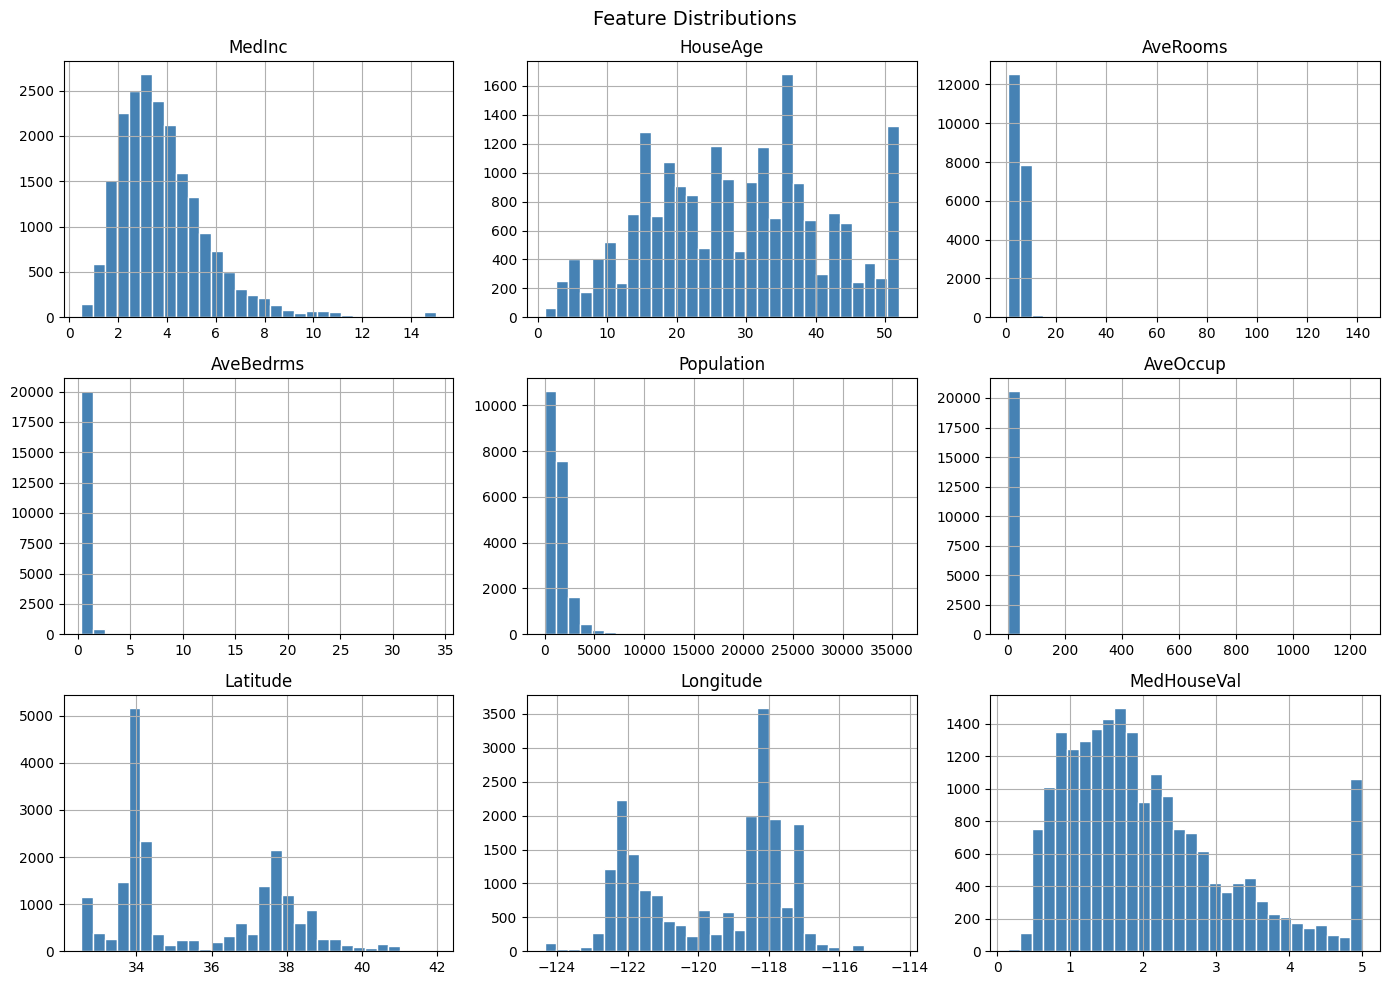

In [4]:
# Plot distributions of all features
df.hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

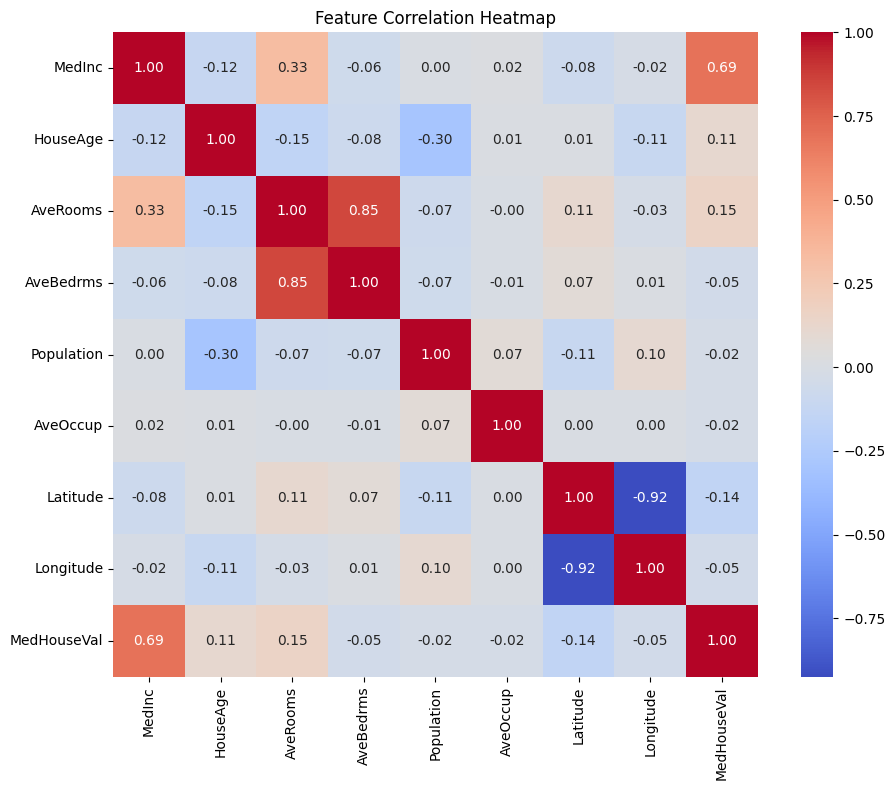

In [5]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()

In [6]:
# Select features and target
X = df.drop(columns='MedHouseVal')
y = df['MedHouseVal']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for linear regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 16512
Testing samples:  4128


In [7]:
# Train linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)

print("Model training complete!")
print("\nCoefficients (feature weights):")
for feat, coef in zip(X.columns, model.coef_):
    print(f"  {feat:20s}: {coef:.4f}")

Model training complete!

Coefficients (feature weights):
  MedInc              : 0.8544
  HouseAge            : 0.1225
  AveRooms            : -0.2944
  AveBedrms           : 0.3393
  Population          : -0.0023
  AveOccup            : -0.0408
  Latitude            : -0.8969
  Longitude           : -0.8698


In [8]:
mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2   = r2_score(y_test, y_pred)

print("=" * 35)
print("        MODEL EVALUATION")
print("=" * 35)
print(f"  MAE  : {mae:.4f}  (in $100,000s)")
print(f"  RMSE : {rmse:.4f}  (in $100,000s)")
print(f"  R²   : {r2:.4f}  (1.0 = perfect)")
print("=" * 35)

        MODEL EVALUATION
  MAE  : 0.5332  (in $100,000s)
  RMSE : 0.7456  (in $100,000s)
  R²   : 0.5758  (1.0 = perfect)


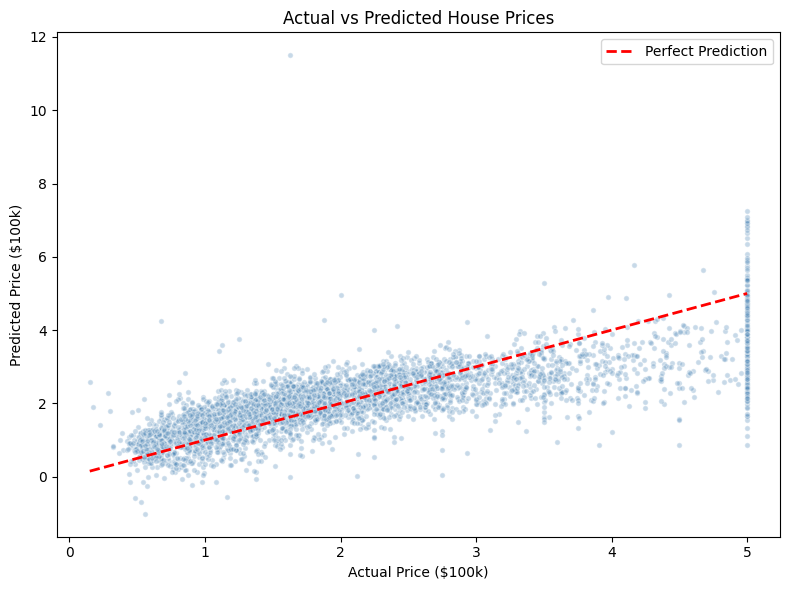

In [9]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', edgecolors='white', s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($100k)')
plt.ylabel('Predicted Price ($100k)')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

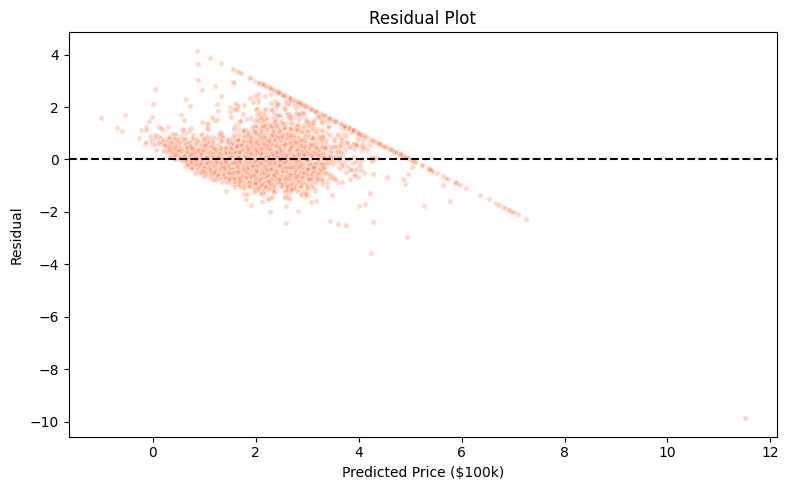

In [10]:
# Residual plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='coral', edgecolors='white', s=15)
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.xlabel('Predicted Price ($100k)')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()

In [11]:
# Save model and scaler
with open('linear_regression_model.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler}, f)

print("Model saved as 'linear_regression_model.pkl'")

Model saved as 'linear_regression_model.pkl'
